In [29]:
#pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
automobile = fetch_ucirepo(id=10) 
  
# data (as pandas dataframes) 
df = automobile.data.features 
df

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,num-of-cylinders,engine-type,curb-weight,height,width,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,dohc,2548,48.8,64.1,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,dohc,2548,48.8,64.1,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,6,ohcv,2823,52.4,65.5,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,4,ohc,2337,54.3,66.2,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,5,ohc,2824,54.3,66.4,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845.0,28,23,5400.0,114.0,9.5,3.15,3.78,mpfi,141,4,ohc,2952,55.5,68.9,188.8,109.1,front,rwd,sedan,4.0,std,gas,volvo,95.0
201,19045.0,25,19,5300.0,160.0,8.7,3.15,3.78,mpfi,141,4,ohc,3049,55.5,68.8,188.8,109.1,front,rwd,sedan,4.0,turbo,gas,volvo,95.0
202,21485.0,23,18,5500.0,134.0,8.8,2.87,3.58,mpfi,173,6,ohcv,3012,55.5,68.9,188.8,109.1,front,rwd,sedan,4.0,std,gas,volvo,95.0
203,22470.0,27,26,4800.0,106.0,23.0,3.40,3.01,idi,145,6,ohc,3217,55.5,68.9,188.8,109.1,front,rwd,sedan,4.0,turbo,diesel,volvo,95.0


In [2]:
df.dropna(subset=["price"], inplace=True)

In [3]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Use price as the regression target (symboling is not the target for price regression)
y = df['price']

# Build feature set by removing the target column
x = df.drop(columns=["price"])

# Identify column types
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

# Preprocessing for numeric and categorical columns
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Regression model
model = RandomForestRegressor()

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Train
regression_pipeline.fit(X_train, y_train)

print(f"Train rows: {X_train.shape[0]}")
print(f"Test rows:  {X_test.shape[0]}")

Train rows: 160
Test rows:  41


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict
y_pred = regression_pipeline.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Regression Results (Automobile Price)")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2  : {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})
comparison_df["Absolute_Error"] = (comparison_df["Actual"] - comparison_df["Predicted"]).abs()
comparison_df

Regression Results (Automobile Price)
MAE : 1,904.71
RMSE: 2,971.39
R2  : 0.9278


,Actual,Predicted,Absolute_Error
0,8249.0,7257.040000,991.960000
1,41315.0,30630.130000,10684.870000
2,6855.0,6254.530000,600.470000
3,9258.0,8027.910000,1230.090000
4,11850.0,13186.185000,1336.185000
5,5572.0,5855.540000,283.540000
6,35056.0,33670.180000,1385.820000
7,9988.0,10884.400000,896.400000
8,15998.0,17267.100000,1269.100000
9,35550.0,33364.730000,2185.270000


In [30]:
df.head()

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,num-of-cylinders,engine-type,curb-weight,height,width,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,dohc,2548,48.8,64.1,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,4,dohc,2548,48.8,64.1,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,6,ohcv,2823,52.4,65.5,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,4,ohc,2337,54.3,66.2,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,5,ohc,2824,54.3,66.4,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0


In [33]:
df.dropna(inplace=True)

Correlation Matrix:
                   highway-mpg  city-mpg  peak-rpm  horsepower  \
highway-mpg           1.000000  0.971999 -0.032777   -0.827941   
city-mpg              0.971999  1.000000 -0.052929   -0.837214   
peak-rpm             -0.032777 -0.052929  1.000000    0.074057   
horsepower           -0.827941 -0.837214  0.074057    1.000000   
compression-ratio     0.221483  0.278332 -0.416769   -0.162305   
stroke               -0.012934 -0.020055 -0.011312    0.148804   
bore                 -0.590850 -0.590440 -0.312269    0.560239   
engine-size          -0.714095 -0.699139 -0.284686    0.812073   
num-of-cylinders     -0.519366 -0.484712 -0.118165    0.618514   
curb-weight          -0.789338 -0.762155 -0.259988    0.790095   
height               -0.226136 -0.199737 -0.245864    0.034317   
width                -0.693339 -0.666684 -0.232216    0.681872   
length               -0.724599 -0.724544 -0.234074    0.672063   
wheel-base           -0.611750 -0.580657 -0.289234    0.

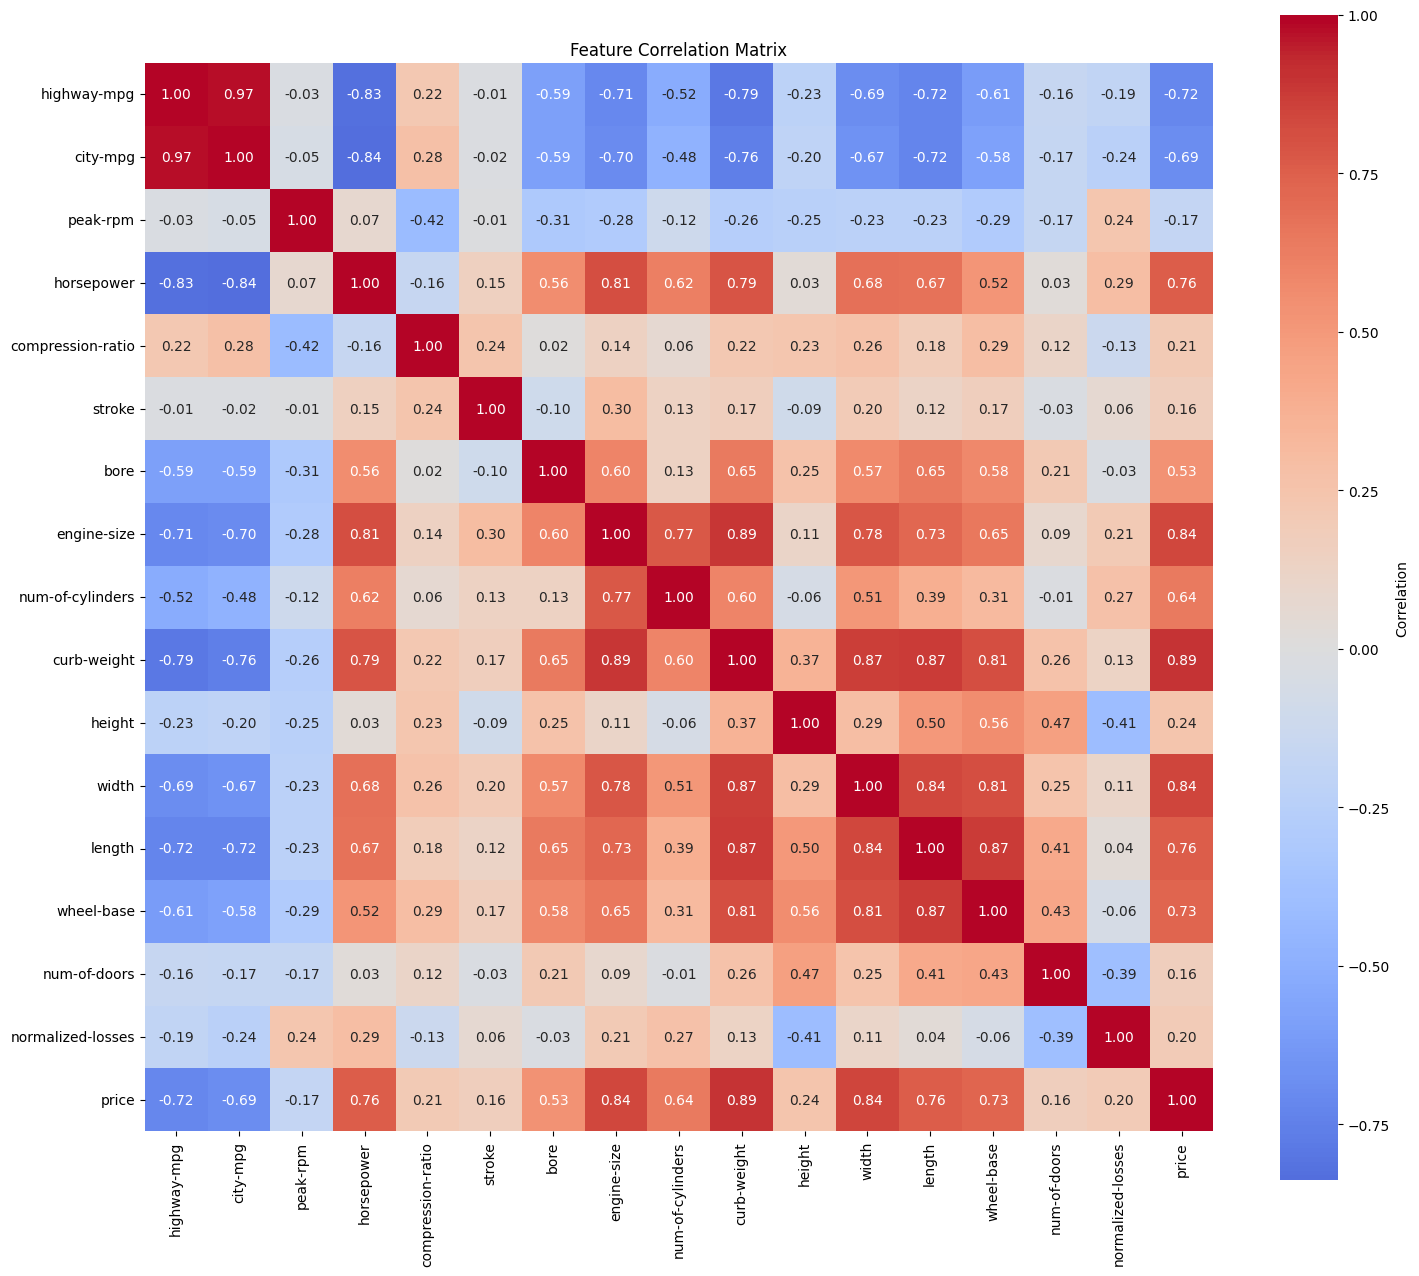


Highly Correlated Feature Pairs (|correlation| > 0.8):
highway-mpg <-> city-mpg: 0.972
highway-mpg <-> horsepower: -0.828
city-mpg <-> horsepower: -0.837
horsepower <-> engine-size: 0.812
engine-size <-> curb-weight: 0.889
engine-size <-> price: 0.841
curb-weight <-> width: 0.871
curb-weight <-> length: 0.871
curb-weight <-> wheel-base: 0.810
curb-weight <-> price: 0.894
width <-> length: 0.838
width <-> wheel-base: 0.815
width <-> price: 0.843
length <-> wheel-base: 0.872


In [38]:
from matplotlib import pyplot as plt
import seaborn as sns
# Calculate correlation matrix
correlation_matrix = df[numeric_features + ['price']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(15, 13))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Find highly correlated features
print("\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

In [8]:
pd.set_option('display.max_columns', 30)

In [28]:
df.head()

""


In [ ]:
data = {"highway-mpg" : 10,"city-mpg" : 25,"peak-rpm" : 5000,"horsepower" : 100,"compression-ratio" : 10,"stroke" : 3.5,'bore' : 3.0,"fuel-system" : "mpfi","engine-size" : 130,"num-of-cylinders" : 2,"engine-type" : "ohc","curb-weight" : 2000,"height" : 50,"width" : 70,"length" : 180,"wheel-base" : 100,"engine-location" : "front","drive-wheels" : "fwd","body-style" : "convertible","num-of-doors" : 2,"aspiration" : "std","fuel-type" : "gas","make" : "toyota","normalized-losses" : 150}


test_df =  pd.DataFrame(data, index=[0])

regression_pipeline.predict(test_df)



array([11248.3475])

In [42]:
import pickle
with open('regression_pipeline.pkl', 'wb') as f:
    pickle.dump(regression_pipeline, f)